In [ ]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import print_wise, decode_matlab_strings, load_img_natraster, TimeSeries, BrainAreas, dRSA, get_relevant_output_layers
from general_utils.II import dynInformationImbalance, init_static_dynII, compute_static_dynII
from general_utils.static_dRSA import init_static_dRSA_dynII, compute_static_dRSA_dynII, init_static_dRSA, compute_static_dRSA
from image_processing.computational_models import map_image_order_from_ann_to_monkey


In [2]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'three0' #'paul'
    date: str =  '250313' #'230204'
    img_size = 384
    folder_name = 'talia_20each_tizi' # 'fewer_occlusion'
    new_fs = 100
    signal_RDM_metric = 'euclidean'
    model_RDM_metric = 'cosine'
    k = 1
    model_name = 'vit_l_16'
    pkg = 'timm'
    img_size = 384
    pooling = 'mean'
    layer_name = 'blocks.1.mlp.fc2'
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)

In [3]:
raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)

In [4]:
dataset = ImageFolder(
    root=f"{paths['livingstone_lab']}/Stimuli/{cfg.folder_name}/",
    is_valid_file=lambda x: not x.endswith("Thumbs.db"), 
    allow_empty=True, 
)

In [5]:
idx_ord = map_image_order_from_ann_to_monkey(paths, cfg.monkey_name, cfg.date, dataset)

In [6]:
ba_obj = BrainAreas("three0")

In [7]:
ba_raster = ba_obj.slice_brain_area(raster, [0, 20])

# II and dRSA

15:04:54 - rank 0 model saved at /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.0.mlp.fc2_100Hz.npz and /Users/tizianocausin/livingstone_lab_local/tiziano/results/static_dRSA_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.0.mlp.fc2_100Hz.npz
15:04:54 - rank 0 model saved at /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.1.mlp.fc2_100Hz.npz and /Users/tizianocausin/livingstone_lab_local/tiziano/results/static_dRSA_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.1.mlp.fc2_100Hz.npz
15:04:54 - rank 0 model saved at /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.2.mlp.fc2_100Hz.npz and /Users/tizianocausin/livingstone_lab_local/tiziano/results/static_dRSA_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.2.mlp.fc2_100Hz.npz
15:04:55 -

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


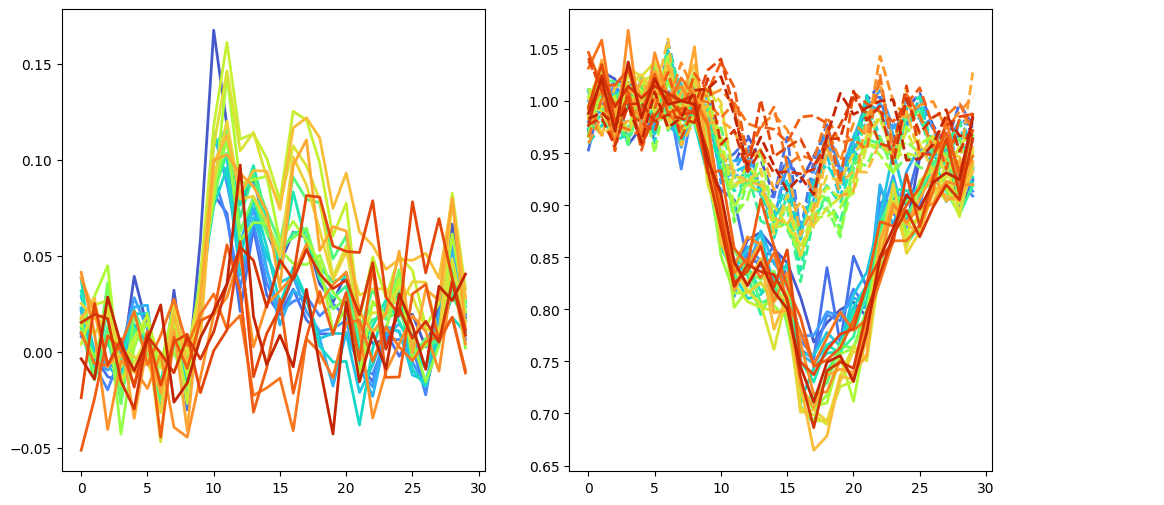

In [11]:
from general_utils.plots import truncate_colormap
base_cmap = plt.cm.turbo
cmap = truncate_colormap(base_cmap, 0.10, 0.90)
perm = np.random.permutation(len(idx_ord))
drsa_obj, dyn_ii_obj = init_static_dRSA_dynII(ba_raster, cfg.signal_RDM_metric, cfg.model_RDM_metric, cfg.k)
fig, ax = plt.subplots(1,2, figsize=(12, 6));
for i_col, l in enumerate(layers):

    color = cmap(i_col / (len(layers) - 1))
    compute_static_dRSA_dynII(paths, 0, l, drsa_obj, dyn_ii_obj, cfg.monkey_name, cfg.date, "AIT", idx_ord, cfg.folder_name, cfg.model_name, cfg.img_size, cfg.pooling)
    save_name_drsa = f"{paths['livingstone_lab']}/tiziano/results/static_drsa_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{cfg.k}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{cfg.k}_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    drsa = np.load(save_name_drsa)["arr_0"]
    A2B = np.load(save_name_A2B)["arr_0"]
    B2A = np.load(save_name_B2A)["arr_0"]
    ax[0].plot(drsa, color=color, linewidth=2)
    ax[1].plot(A2B, color=color, linewidth=2, linestyle="--")
    ax[1].plot(B2A, color=color, linewidth=2)

fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
);

In [57]:
def compute_static_dRSA_dynII(paths, rank, layer_name, drsa_obj, dyn_ii_obj, monkey_name, date, idx_ord, folder_name, model_name, img_size, pooling) -> tuple["TimeSeries", "TimeSeries", "TimeSeries"]:
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{dyn_ii_obj.k}_{drsa_obj.signal_RDM_metric}-{drsa_obj.model_RDM_metric}_{monkey_name}_{date}_{model_name}_{img_size}_{layer_name}_{dyn_ii_obj.get_RDM_timeseries("signal").get_fs()}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{dyn_ii_obj.k}_{drsa_obj.signal_RDM_metric}-{drsa_obj.model_RDM_metric}_{monkey_name}_{date}_{model_name}_{img_size}_{layer_name}_{dyn_ii_obj.get_RDM_timeseries("signal").get_fs()}Hz.npz"
    save_name_drsa = f"{paths['livingstone_lab']}/tiziano/results/static_dRSA_{drsa_obj.signal_RDM_metric}-{drsa_obj.model_RDM_metric}_{monkey_name}_{date}_{model_name}_{img_size}_{layer_name}_{drsa_obj.get_RDM_timeseries("signal").get_fs()}Hz.npz"
    if os.path.exists(save_name_drsa) and os.path.exists(save_name_A2B) and os.path.exists(save_name_B2A):
        print_wise(f"model already exists at {save_name_A2B}", rank=rank)
    else:
        if not hasattr(drsa_obj, "signal_RDM_timeseries"):
            raise AttributeError("drsa_obj must have 'signal_RDM_timeseries'")
        # end if not hasattr(drsa_obj, "signal_RDM_timeseries"):
        if not hasattr(dyn_ii_obj, "signal_distance_ranks_timeseries"):
            raise AttributeError("dyn_ii_obj must have 'signal_distance_ranks_timeseries'")
        # end if not hasattr(dyn_ii_obj, "signal_distance_ranks_timeseries"):
        feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{folder_name}_{model_name}_{img_size}_{layer_name}_features_{pooling}pool.npz"
        features = np.load(feats_filename)["arr_0"][:, idx_ord]
        drsa_obj.compute_RDM(features, "model")
        drsa = drsa_obj.compute_static_dRSA()
        dyn_ii_obj.set_RDM(drsa_obj.get_RDM("model"), "model")
        dyn_ii_obj.compute_distance_ranks("model")
        dyn_ii = dyn_ii_obj.compute_both_static_dynII()
        np.savez_compressed(save_name_drsa, drsa.get_array())
        np.savez_compressed(save_name_A2B, dyn_ii[0].get_array())
        np.savez_compressed(save_name_B2A, dyn_ii[1].get_array())
        print_wise(f"model saved at {save_name_A2B} and {save_name_drsa}", rank=rank)
    # end if os.path.exists(save_name_drsa) and os.path.exists(save_name_A2B) and os.path.exists(save_name_B2A):
# EOF


# Information Imbalance

In [ ]:
def init_static_dynII(ba_raster: "TimeSeries", signal_RDM_metric, model_RDM_metric, k) -> "dynInformationImbalance":
    drsa_obj = dRSA(signal_RDM_metric, model_RDM_metric)
    drsa_obj.compute_RDM_timeseries(ba_raster, "signal")
    dyn_ii_obj = dynInformationImbalance(signal_RDM_metric, model_RDM_metric, k)
    dyn_ii_obj.compute_RDM_timeseries(ba_raster, "signal")
    dyn_ii_obj.compute_distance_ranks_timeseries("signal")
    return  dyn_ii_obj
# EOF

def compute_static_dynII(paths: dict[str: str], rank: int, layer_name: str, dyn_ii_obj: "dynInformationImbalance", idx_ord: np.ndarray[int], monkey_name, date, folder_name: str, model_name: str, img_size: int, pooling: str) -> tuple["TimeSeries", "TimeSeries"]:    
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_k{dyn_ii_obj.k}_{drsa_obj.signal_RDM_metric}-{drsa_obj.model_RDM_metric}_{monkey_name}_{date}_{model_name}_{img_size}_{layer_name}_{dyn_ii_obj.get_RDM_timeseries("signal").get_fs()}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_k{dyn_ii_obj.k}_{drsa_obj.signal_RDM_metric}-{drsa_obj.model_RDM_metric}_{monkey_name}_{date}_{model_name}_{img_size}_{layer_name}_{dyn_ii_obj.get_RDM_timeseries("signal").get_fs()}Hz.npz"
    if os.path.exists(save_name_A2B) and os.path.exists(save_name_B2A):
        print_wise(f"model already exists at {save_name_A2B}", rank=rank)
    else:
        if not hasattr(dyn_ii_obj, "signal_distance_ranks_timeseries"):
            raise AttributeError("dyn_ii_obj must have 'signal_distance_ranks_timeseries'")
        # end if not hasattr(dyn_ii_obj, "signal_distance_ranks_timeseries"):
        feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{folder_name}_{model_name}_{img_size}_{layer_name}_features_{pooling}pool.npz"
        features = np.load(feats_filename)["arr_0"][:, idx_ord]
        dyn_ii_obj.compute_RDM(features, "model")
        dyn_ii_obj.compute_distance_ranks("model")
        dyn_ii = dyn_ii_obj.compute_both_static_dynII()
        np.savez_compressed(save_name_A2B, dyn_ii[0].get_array())
        np.savez_compressed(save_name_B2A, dyn_ii[1].get_array())
        print_wise(f"model saved at {save_name_A2B}", rank=rank)
    # end if os.path.exists(save_name_A2B) and os.path.exists(save_name_B2A):
# EOF


15:06:56 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.0.mlp.fc2_100Hz.npz
15:06:56 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.1.mlp.fc2_100Hz.npz
15:06:56 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.2.mlp.fc2_100Hz.npz
15:06:56 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.3.mlp.fc2_100Hz.npz
15:06:56 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/results/dynII_A2B_k1_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.4.mlp.fc2_100Hz.npz
15:06:56 - rank 0 model already exists at /Users/tizian

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


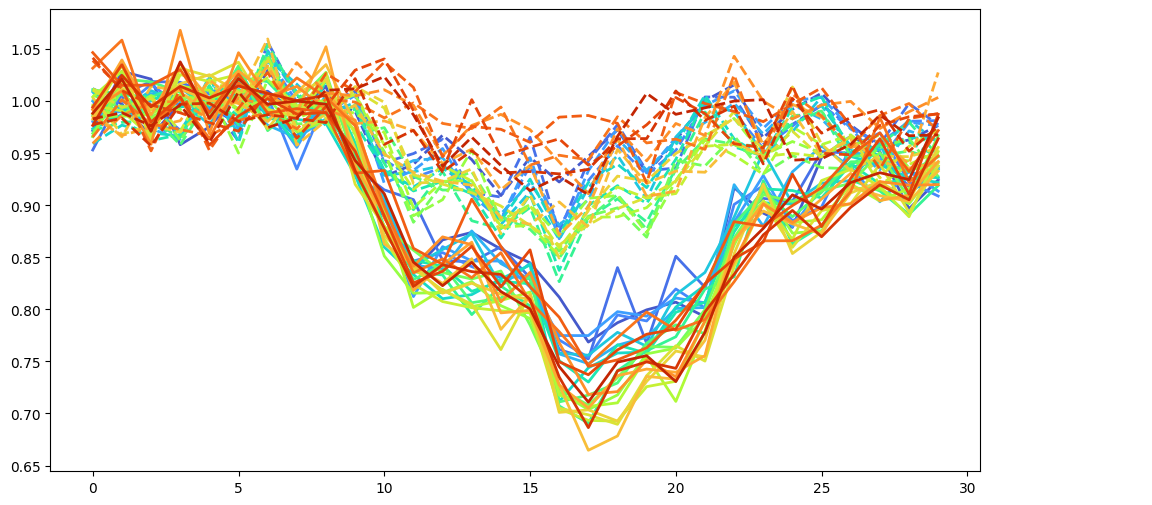

In [11]:
from general_utils.plots import truncate_colormap
base_cmap = plt.cm.turbo
cmap = truncate_colormap(base_cmap, 0.10, 0.90)
perm = np.random.permutation(len(idx_ord))
fig, ax = plt.subplots(1, figsize=(12, 6))
dyn_ii_obj = init_static_dynII(ba_raster, cfg.signal_RDM_metric, cfg.model_RDM_metric, cfg.k)
for i_col, l in enumerate(layers):
    
    color = cmap(i_col / (len(layers) - 1))
    compute_static_dynII(paths, 0, l, dyn_ii_obj, idx_ord, cfg.monkey_name, cfg.date, "AIT", cfg.folder_name, cfg.model_name, cfg.img_size, cfg.pooling)
    save_name_A2B = f"{paths['livingstone_lab']}/tiziano/results/dynII_A2B_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    save_name_B2A = f"{paths['livingstone_lab']}/tiziano/results/dynII_B2A_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
    A2B = np.load(save_name_A2B)["arr_0"]
    B2A = np.load(save_name_B2A)["arr_0"]
    ax.plot(A2B, color=color, linewidth=2, linestyle="--")
    ax.plot(B2A, color=color, linewidth=2)
fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
);

# dRSA

In [ ]:

def init_static_dRSA(ba_raster: "TimeSeries", signal_RDM_metric, model_RDM_metric) -> "dRSA":
    drsa_obj = dRSA(signal_RDM_metric, model_RDM_metric)
    drsa_obj.compute_RDM_timeseries(ba_raster, "signal")
    return  dyn_ii_obj
# EOF

def compute_static_dRSA(paths: dict[str: str], rank: int, layer_name: str, drsa_obj, idx_ord: np.ndarray[int], monkey_name, date,  folder_name: str, model_name: str, img_size: int, pooling: str) -> "TimeSeries":    
    save_name = f"{paths['livingstone_lab']}/tiziano/results/static_dRSA_{drsa_obj.signal_RDM_metric}-{drsa_obj.model_RDM_metric}_{monkey_name}_{date}_{model_name}_{img_size}_{layer_name}_{drsa_obj.get_RDM_timeseries().get_fs()}Hz.npz"
    if os.path.exists(save_name):
        print_wise(f"model already exists at {save_name}", rank=rank)
    else:
        if not hasattr(drsa_obj, "signal_RDM_timeseries"):
            raise AttributeError("drsa_obj must have 'signal_RDM_timeseries'")
        # end if not hasattr(drsa_obj, "signal_RDM_timeseries"):
        feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{folder_name}_{model_name}_{img_size}_{layer_name}_features_{pooling}pool.npz"
        features = np.load(feats_filename)["arr_0"][:, idx_ord]
        drsa_obj.compute_RDM(features, "model")
        drsa = drsa_obj.compute_static_dRSA()
        np.savez_compressed(save_name, drsa.get_array())
        print_wise(f"model saved at {save_name}", rank=rank)
    # end if os.path.exists(save_name):
# EOF


15:07:02 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/results/static_dRSA_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.0.mlp.fc2_100Hz.npz
15:07:02 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/results/static_dRSA_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.1.mlp.fc2_100Hz.npz
15:07:02 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/results/static_dRSA_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.2.mlp.fc2_100Hz.npz
15:07:02 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/results/static_dRSA_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.3.mlp.fc2_100Hz.npz
15:07:02 - rank 0 model already exists at /Users/tizianocausin/livingstone_lab_local/tiziano/results/static_dRSA_euclidean-cosine_three0_250313_AIT_vit_l_16_384_blocks.4.mlp.fc2_100Hz.npz
15:07:02 - rank 0 model already exists at /Users/tizianocaus

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


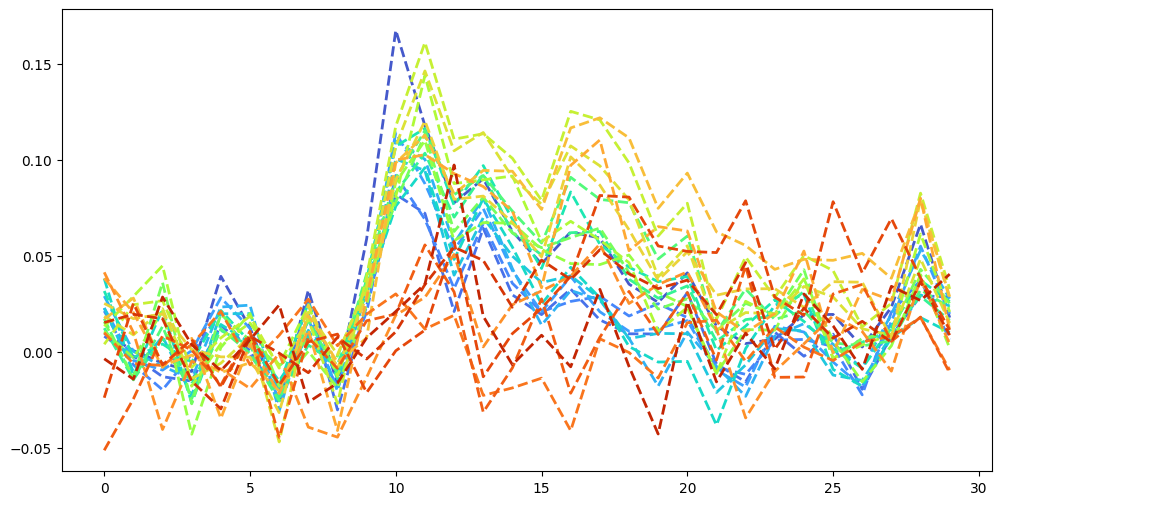

In [12]:
from general_utils.plots import truncate_colormap
base_cmap = plt.cm.turbo
cmap = truncate_colormap(base_cmap, 0.10, 0.90)
perm = np.random.permutation(len(idx_ord))
fig, ax = plt.subplots(1, figsize=(12, 6))
drsa_obj = init_static_dRSA(ba_raster, cfg.signal_RDM_metric, cfg.model_RDM_metric)
for i_col, l in enumerate(layers):
    try:
        color = cmap(i_col / (len(layers) - 1))
        compute_static_dRSA(paths, 0, l, drsa_obj, idx_ord, cfg.monkey_name, cfg.date, "AIT", cfg.folder_name, cfg.model_name, cfg.img_size, cfg.pooling)
        save_name_drsa = f"{paths['livingstone_lab']}/tiziano/results/static_drsa_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{l}_{cfg.new_fs}Hz.npz"
        drsa = np.load(save_name_drsa)["arr_0"]
        ax.plot(drsa, color=color, linewidth=2, linestyle="--")
    except FileNotFoundError:
        pass
fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
);

# TO DO
- move funcs to src and comment
- run them separately on scripts (test on cluster)
- define brain areas in monkeys